# Lab 01 — DC Motor Plant Foundation

First step toward **Agentic Orchestration of DC Motor Control**: define the plant (system dynamics) before any controller or agent.

In this lab we:
1. Define a standard armature-controlled DC motor with practical open-source parameters.
2. Simulate and plot the **open-loop** angular speed response to a voltage step.
3. Close the loop with a **PID speed controller** and compute performance metrics.

Later labs will add evaluation harnesses, optional PID tuning agents, and orchestration. Hardware deployment comes last.

## Plant model (speed from armature voltage)

Electrical and mechanical equations:

$$
L\dot{i} + R i = V - K_e \omega, \qquad
J\dot{\omega} + b \omega = K_t i
$$

With \(K_t = K_e = K\) in SI units, the transfer function is:

$$
G(s) = \frac{\omega(s)}{V(s)} = \frac{K}{(Js + b)(Ls + R) + K^2}
$$


## 1. Motor parameters

Parameters below are the widely used open educational example from the
[Control Tutorials for MATLAB and Simulink (CTMS) — DC Motor Speed](https://ctms.engin.umich.edu/CTMS/index.php?example=MotorSpeed&section=SystemModeling)
(University of Michigan). They are SI-consistent and practical for simulation labs.


In [1]:
# CTMS DC motor speed example parameters (SI units)
# Source: https://ctms.engin.umich.edu/CTMS/index.php?example=MotorSpeed&section=SystemModeling

J = 0.01   # rotor inertia [kg·m^2]
b = 0.1    # viscous friction coefficient [N·m·s/rad]
K = 0.01   # motor constant Kt = Ke [N·m/A] = [V·s/rad]
R = 1.0    # armature resistance [ohm]
L = 0.5    # armature inductance [H]

V_step = 1.0  # open-loop step input voltage [V]

print("DC motor parameters (CTMS):")
print(f"  J = {J} kg·m²")
print(f"  b = {b} N·m·s/rad")
print(f"  K = {K} (Kt = Ke)")
print(f"  R = {R} Ω")
print(f"  L = {L} H")
print(f"  V_step = {V_step} V")


DC motor parameters (CTMS):
  J = 0.01 kg·m²
  b = 0.1 N·m·s/rad
  K = 0.01 (Kt = Ke)
  R = 1.0 Ω
  L = 0.5 H
  V_step = 1.0 V


## 2. Open-loop step response

Build \(G(s) = \omega(s)/V(s)\) and apply a constant armature voltage step.
This shows the plant's natural dynamics (rise/settling behavior and steady-state speed) with **no feedback controller**.


Approximate steady-state speed: 0.0996 rad/s


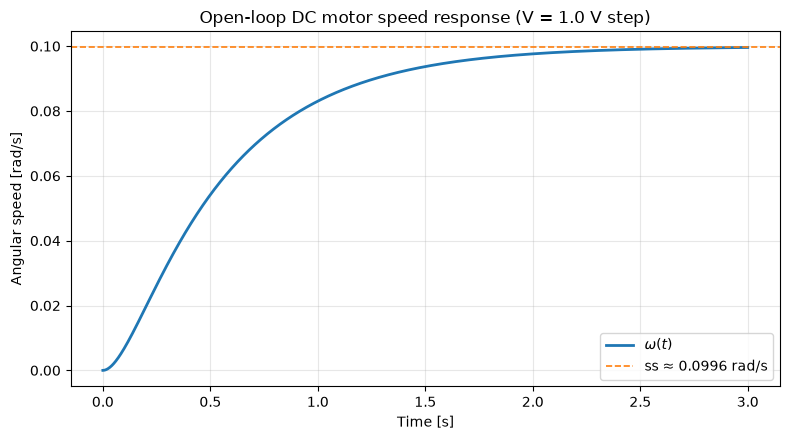

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# G(s) = K / [(J s + b)(L s + R) + K^2]
# Expanded denominator: (J*L) s^2 + (J*R + b*L) s + (b*R + K^2)
num = [K]
den = [J * L, J * R + b * L, b * R + K**2]

sys = signal.TransferFunction(num, den)

t = np.linspace(0, 3, 1001)
t_out, omega = signal.step(sys, T=t)
omega = V_step * omega  # scale unit-step response to V_step volts

omega_ss = omega[-1]
print(f"Approximate steady-state speed: {omega_ss:.4f} rad/s")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(t_out, omega, color="C0", linewidth=2, label=r"$\omega(t)$")
ax.axhline(omega_ss, color="C1", linestyle="--", linewidth=1.2, label=f"ss ≈ {omega_ss:.4f} rad/s")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Angular speed [rad/s]")
ax.set_title(f"Open-loop DC motor speed response (V = {V_step} V step)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


### What this plot shows

- With a constant voltage and **no feedback**, speed rises smoothly toward a steady value set by the motor parameters and \(V\).
- This CTMS plant is typically **overdamped** (little or no overshoot) — useful as a clean baseline before we add PID.
- Open-loop voltage alone cannot reject load disturbances or enforce a commanded setpoint; that is why the next section adds closed-loop PID control.


## 3. Closed-loop PID speed control

Feedback loop:

$$
e = \omega_{\mathrm{ref}} - \omega, \qquad
u = K_p e + K_i \int e\,dt + K_d \dot{e}
$$

Voltage \(u\) (armature command) is optionally saturated. Gains below follow the common CTMS educational PID starting point for this plant
([DC Motor Speed: PID Controller Design](https://ctms.engin.umich.edu/CTMS/index.php?example=MotorSpeed&section=ControlPID)).


In [3]:
# Closed-loop simulation settings
omega_ref = 1.0   # speed setpoint [rad/s]
dt = 0.001        # sample time [s]
t_final = 3.0     # simulation horizon [s]

# CTMS-style educational PID gains (baseline — not auto-tuned)
Kp = 100.0
Ki = 200.0
Kd = 10.0

V_min, V_max = -12.0, 12.0  # armature voltage limits [V]

print("Closed-loop PID settings:")
print(f"  omega_ref = {omega_ref} rad/s")
print(f"  dt = {dt} s, t_final = {t_final} s")
print(f"  Kp = {Kp}, Ki = {Ki}, Kd = {Kd}")
print(f"  V in [{V_min}, {V_max}] V")


Closed-loop PID settings:
  omega_ref = 1.0 rad/s
  dt = 0.001 s, t_final = 3.0 s
  Kp = 100.0, Ki = 200.0, Kd = 10.0
  V in [-12.0, 12.0] V


In [4]:
def simulate_pid_speed_control(
    J, b, K, R, L,
    Kp, Ki, Kd,
    omega_ref,
    dt=0.001,
    t_final=3.0,
    V_min=-12.0,
    V_max=12.0,
):
    """Discrete closed-loop sim: PID -> saturated voltage -> DC motor ODEs (Euler)."""
    n = int(np.round(t_final / dt)) + 1
    t = np.linspace(0.0, t_final, n)

    i = 0.0
    omega = 0.0
    integ = 0.0
    e_prev = omega_ref - omega

    omega_hist = np.zeros(n)
    u_hist = np.zeros(n)
    e_hist = np.zeros(n)
    sat_hist = np.zeros(n, dtype=bool)

    for k in range(n):
        e = omega_ref - omega
        de = (e - e_prev) / dt if k > 0 else 0.0
        u_unsat = Kp * e + Ki * integ + Kd * de
        u = float(np.clip(u_unsat, V_min, V_max))
        saturated = u != u_unsat

        # Conditional anti-windup: integrate only when not saturating against the error
        if not saturated or (u_unsat > V_max and e < 0) or (u_unsat < V_min and e > 0):
            integ += e * dt

        # Plant: di/dt, d(omega)/dt
        di = (-R * i - K * omega + u) / L
        domega = (K * i - b * omega) / J
        i = i + di * dt
        omega = omega + domega * dt

        omega_hist[k] = omega
        u_hist[k] = u
        e_hist[k] = e
        sat_hist[k] = saturated
        e_prev = e

    return {
        "t": t,
        "omega": omega_hist,
        "u": u_hist,
        "e": e_hist,
        "saturated": sat_hist,
        "omega_ref": omega_ref,
    }


sim = simulate_pid_speed_control(
    J, b, K, R, L, Kp, Ki, Kd, omega_ref,
    dt=dt, t_final=t_final, V_min=V_min, V_max=V_max,
)
print(f"Simulated {len(sim['t'])} steps.")


Simulated 3001 steps.


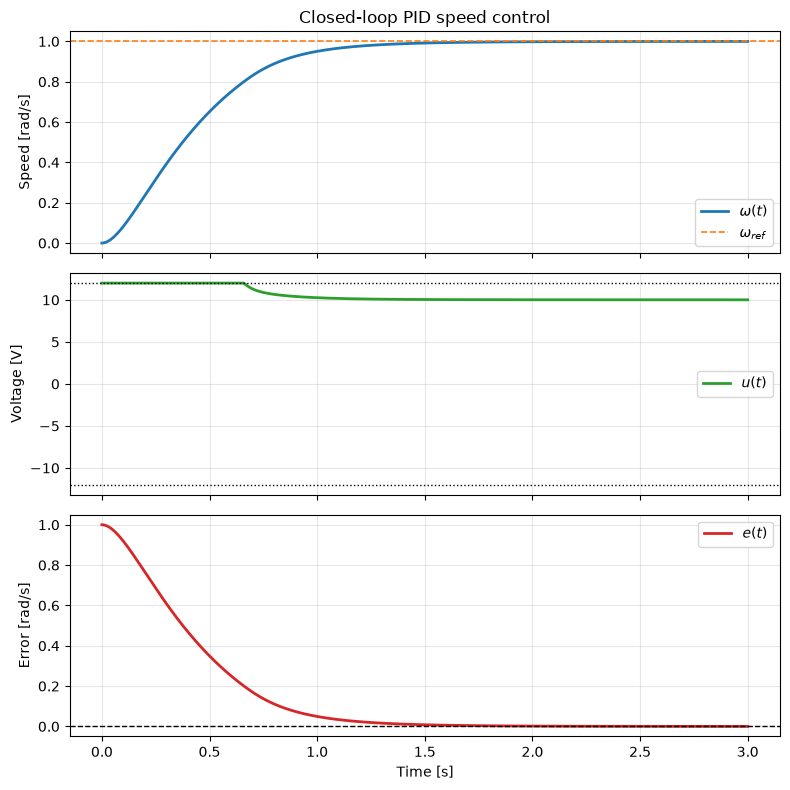

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

axes[0].plot(sim["t"], sim["omega"], color="C0", lw=2, label=r"$\omega(t)$")
axes[0].axhline(sim["omega_ref"], color="C1", ls="--", lw=1.2, label=r"$\omega_{ref}$")
axes[0].set_ylabel("Speed [rad/s]")
axes[0].set_title("Closed-loop PID speed control")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best")

axes[1].plot(sim["t"], sim["u"], color="C2", lw=2, label=r"$u(t)$")
axes[1].axhline(V_max, color="k", ls=":", lw=1)
axes[1].axhline(V_min, color="k", ls=":", lw=1)
axes[1].set_ylabel("Voltage [V]")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best")

axes[2].plot(sim["t"], sim["e"], color="C3", lw=2, label=r"$e(t)$")
axes[2].axhline(0.0, color="k", ls="--", lw=1)
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Error [rad/s]")
axes[2].grid(True, alpha=0.3)
axes[2].legend(loc="best")

fig.tight_layout()
plt.show()


## 4. Performance metrics

Deterministic scores for this step response (reuse later in the Evaluation Node):

| Metric | Meaning |
|--------|--------|
| Rise time | 10% → 90% of \(\omega_{ref}\) |
| Settling time | Enter and stay in ±2% band |
| Overshoot | Peak excess over \(\omega_{ref}\) [%] |
| Steady-state error | \(|\omega_{ref} - \omega(t_f)|\) |
| IAE / ISE / ITAE | Integral error norms |
| Control effort | \(\int |u|\,dt\) |
| Saturation time | Time spent at voltage limits |


In [6]:
def step_performance_metrics(t, y, u, e, saturated, y_ref, settle_band=0.02):
    """Compute standard step-response and effort metrics."""
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    u = np.asarray(u, dtype=float)
    e = np.asarray(e, dtype=float)
    saturated = np.asarray(saturated, dtype=bool)

    # Rise time: 10% -> 90%
    y10, y90 = 0.1 * y_ref, 0.9 * y_ref
    idx10 = np.where(y >= y10)[0]
    idx90 = np.where(y >= y90)[0]
    if len(idx10) and len(idx90) and idx90[0] >= idx10[0]:
        rise_time = t[idx90[0]] - t[idx10[0]]
    else:
        rise_time = np.nan

    # Settling time: last time outside ±settle_band band
    band = settle_band * abs(y_ref)
    outside = np.abs(y - y_ref) > band
    if np.any(outside):
        last_out = np.where(outside)[0][-1]
        settling_time = t[last_out + 1] if last_out + 1 < len(t) else np.nan
    else:
        settling_time = 0.0

    y_peak = float(np.max(y))
    overshoot_pct = max(0.0, (y_peak - y_ref) / abs(y_ref) * 100.0) if y_ref != 0 else np.nan
    ss_error = abs(y_ref - y[-1])

    iae = float(np.trapezoid(np.abs(e), t))
    ise = float(np.trapezoid(e**2, t))
    itae = float(np.trapezoid(t * np.abs(e), t))
    effort = float(np.trapezoid(np.abs(u), t))

    if len(t) > 1:
        dt_arr = np.diff(t, prepend=t[0])
        dt_arr[0] = dt_arr[1] if len(dt_arr) > 1 else 0.0
        sat_time = float(np.sum(dt_arr[saturated]))
    else:
        sat_time = 0.0

    return {
        "rise_time_s": rise_time,
        "settling_time_s": settling_time,
        "overshoot_pct": overshoot_pct,
        "steady_state_error": ss_error,
        "IAE": iae,
        "ISE": ise,
        "ITAE": itae,
        "control_effort": effort,
        "saturation_time_s": sat_time,
    }


metrics = step_performance_metrics(
    sim["t"], sim["omega"], sim["u"], sim["e"], sim["saturated"], sim["omega_ref"]
)

print("PID step-response metrics:")
for key, val in metrics.items():
    if isinstance(val, float) and (np.isnan(val) or np.isinf(val)):
        print(f"  {key}: n/a")
    else:
        print(f"  {key}: {val:.6g}")


PID step-response metrics:
  rise_time_s: 0.713
  settling_time_s: 1.241
  overshoot_pct: 0
  steady_state_error: 7.59504e-05
  IAE: 0.437736
  ISE: 0.275246
  ITAE: 0.14256
  control_effort: 31.6419
  saturation_time_s: 0.661


### Interpretation

- **vs open-loop:** Open-loop for \(V=1\,\mathrm{V}\) settles near \(\approx 0.1\,\mathrm{rad/s}\) and cannot track an arbitrary \(\omega_{ref}\). Closed-loop PID drives speed to the commanded setpoint (here \(1\,\mathrm{rad/s}\)) using feedback.
- **Metrics role:** These numbers are the start of a reusable **scorecard**. Later, a Simulation & Evaluation node will score PID (and eventually MPC / robust / RL) on the same metrics so an orchestrator can compare controllers fairly.
- **Not done yet:** auto PID tuner agent, multi-scenario evaluation, or LLM selection — those come in later phases (`PROJECT_SEQUENCE.txt`).

**Next:** see `Lab_02.ipynb` for the shared evaluation harness (Phase 2).
